In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des colonnes officielles de la NASA
col_names = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]
filenames = ['train_FD001', 'train_FD002', 'train_FD003', 'train_FD004']

# Dictionnaire global pour stocker les 4 datasets nettoyés
dfs = {}

print("=== CHARGEMENT DES DONNÉES EN COURS ===")
for f in filenames:
    # ATTENTION ICI : On utilise f'../data/raw/{f}.txt' pour charger dynamiquement FD001, FD002, FD003, FD004
    df = pd.read_csv(f'../data/raw/{f}.txt', sep=r'\s+', header=None, names=col_names)
    
    # Calcul de la RUL (Remaining Useful Life) spécifique à ce fichier
    max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    
    df = df.merge(max_cycles, on='engine_id', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop(columns=['max_cycle'], inplace=True)
    
    # Stockage dans le dictionnaire
    dfs[f] = df
    print(f"• {f} chargé avec succès : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
print("=======================================")


=== CHARGEMENT DES DONNÉES EN COURS ===
• train_FD001 chargé avec succès : 20631 lignes, 27 colonnes.
• train_FD002 chargé avec succès : 53759 lignes, 27 colonnes.
• train_FD003 chargé avec succès : 24720 lignes, 27 colonnes.
• train_FD004 chargé avec succès : 61249 lignes, 27 colonnes.


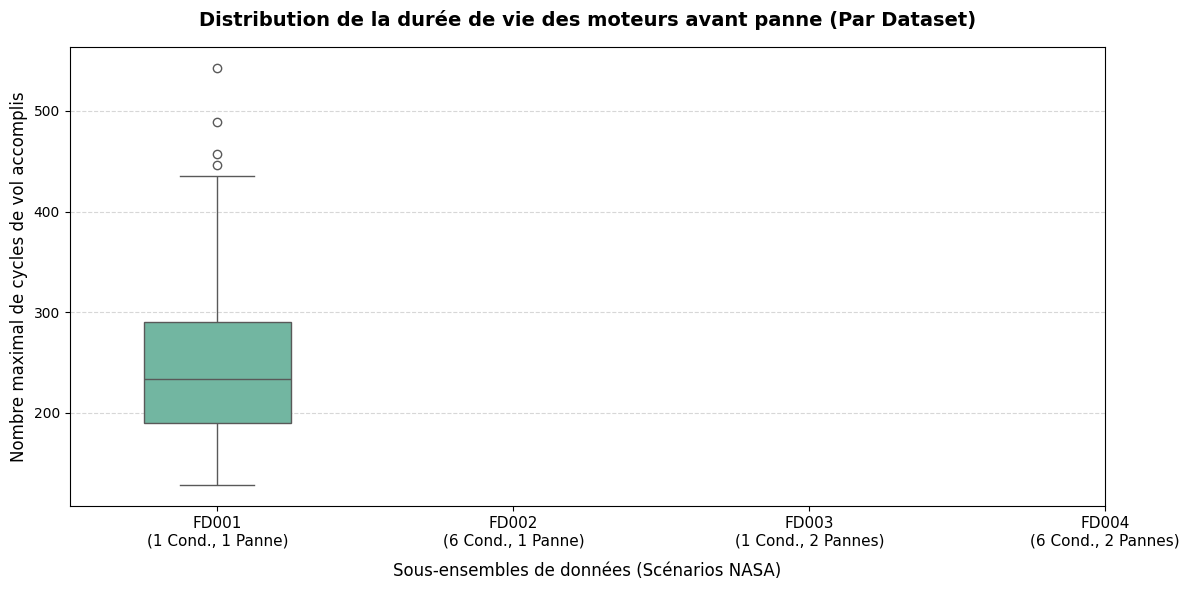

In [7]:
# Préparation des données pour le graphique à partir des vrais fichiers distincts
lifecycle_data = [dfs[f].groupby('engine_id')['cycle'].max() for f in filenames]

# Création de la figure
plt.figure(figsize=(12, 6))
sns.boxplot(data=lifecycle_data, palette="Set2", width=0.5)

# Personnalisation des axes pour la présentation business
plt.xticks(ticks=range(4), labels=[
    'FD001\n(1 Cond., 1 Panne)', 
    'FD002\n(6 Cond., 1 Panne)', 
    'FD003\n(1 Cond., 2 Pannes)', 
    'FD004\n(6 Cond., 2 Pannes)'
], fontsize=11)

plt.title("Distribution de la durée de vie des moteurs avant panne (Par Dataset)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sous-ensembles de données (Scénarios NASA)", fontsize=12, labelpad=10)
plt.ylabel("Nombre maximal de cycles de vol accomplis", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

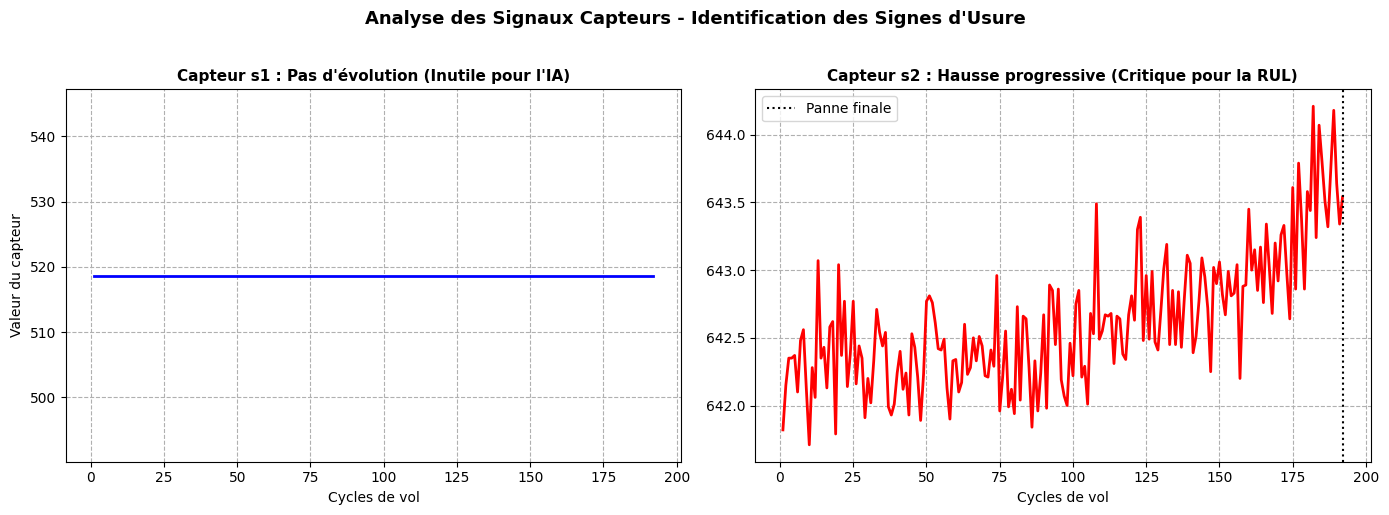

In [9]:
# On prend le premier moteur du premier dataset
moteur_1 = dfs['train_FD001'][dfs['train_FD001']['engine_id'] == 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Capteur s1 : Totalement constant (Inutile)
ax1.plot(moteur_1['cycle'], moteur_1['s1'], color='blue', linewidth=2)
ax1.set_title("Capteur s1 : Pas d'évolution (Inutile pour l'IA)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Cycles de vol")
ax1.set_ylabel("Valeur du capteur")
ax1.grid(True, linestyle='--')

# 2. Capteur s2 : Évolution claire (Indicateur de panne)
ax2.plot(moteur_1['cycle'], moteur_1['s2'], color='red', linewidth=2)
ax2.axvline(x=moteur_1['cycle'].max(), color='black', linestyle=':', label='Panne finale')
ax2.set_title("Capteur s2 : Hausse progressive (Critique pour la RUL)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Cycles de vol")
ax2.grid(True, linestyle='--')
ax2.legend()

plt.suptitle("Analyse des Signaux Capteurs - Identification des Signes d'Usure", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== CALCUL DES KPIS BUSINESS (SUR LES 4 FLOTTES) ===

📈 STATISTIQUES POUR TRAIN_FD001 :
  • Équipements à Haut Risque (RUL <= 30 vols) : 100 moteurs
  • Durée de vie moyenne restante (RUL)       : 0.0 cycles
  • Répartition : 0 Sains | 0 À surveiller | 100 Critiques

📈 STATISTIQUES POUR TRAIN_FD002 :
  • Équipements à Haut Risque (RUL <= 30 vols) : 260 moteurs
  • Durée de vie moyenne restante (RUL)       : 0.0 cycles
  • Répartition : 0 Sains | 0 À surveiller | 260 Critiques

📈 STATISTIQUES POUR TRAIN_FD003 :
  • Équipements à Haut Risque (RUL <= 30 vols) : 100 moteurs
  • Durée de vie moyenne restante (RUL)       : 0.0 cycles
  • Répartition : 0 Sains | 0 À surveiller | 100 Critiques

📈 STATISTIQUES POUR TRAIN_FD004 :
  • Équipements à Haut Risque (RUL <= 30 vols) : 249 moteurs
  • Durée de vie moyenne restante (RUL)       : 0.0 cycles
  • Répartition : 0 Sains | 0 À surveiller | 249 Critiques




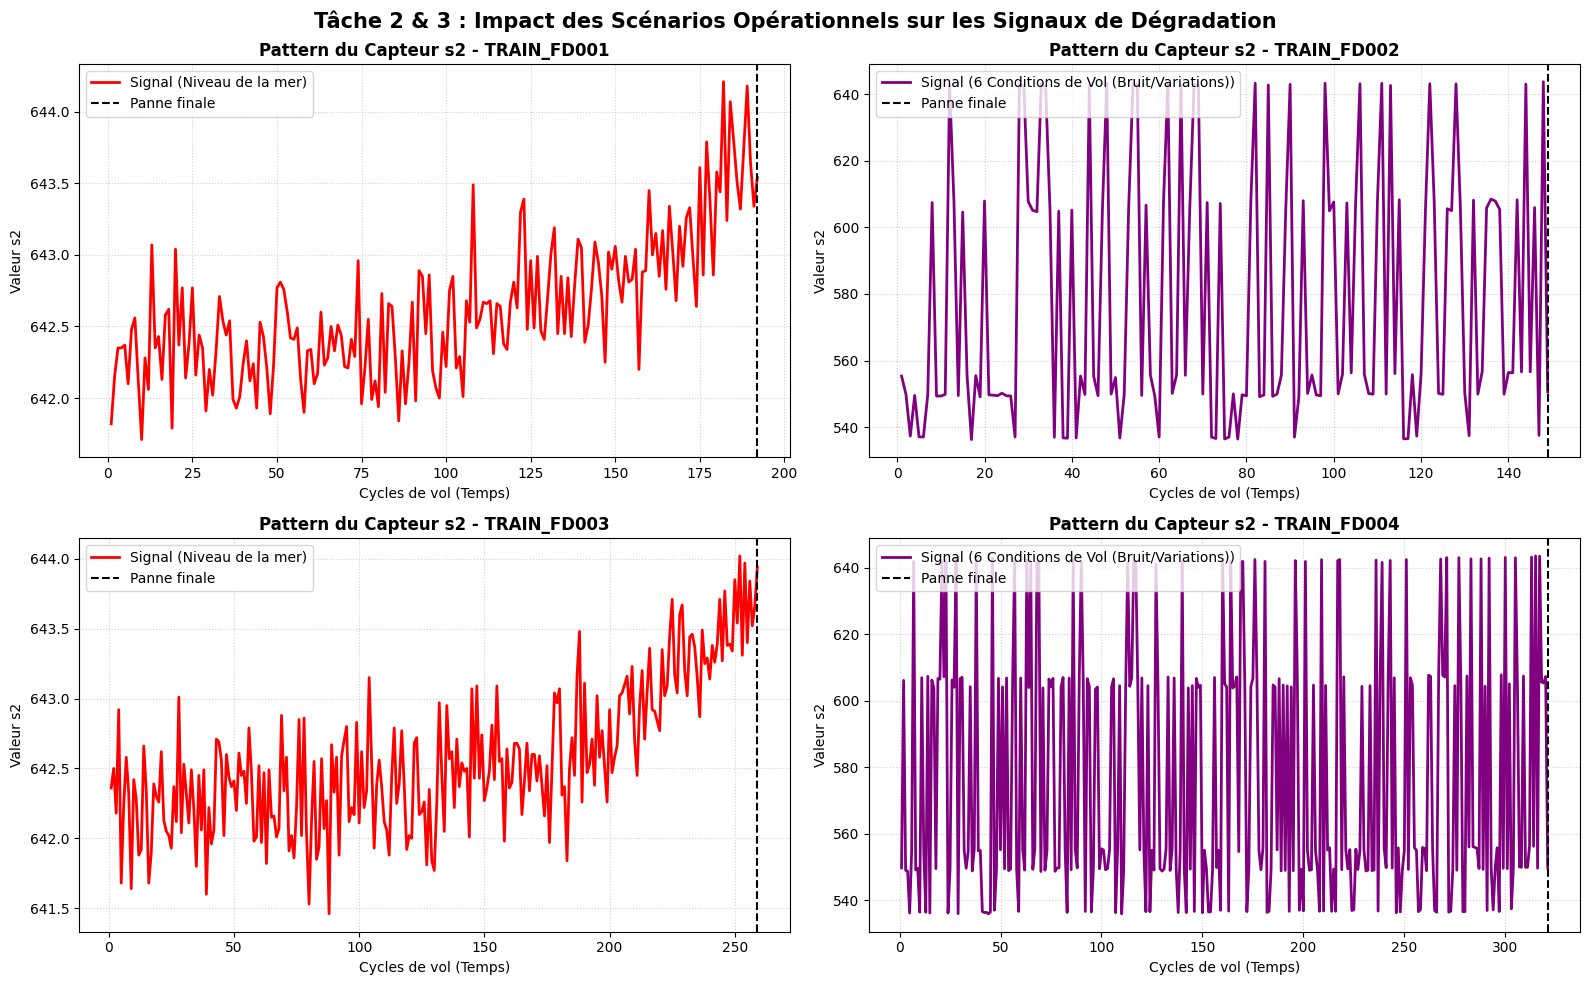

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Analyse et Segmentation des Risques sur les 4 fichiers (Livrable KPIs Business)
print("=== CALCUL DES KPIS BUSINESS (SUR LES 4 FLOTTES) ===")

for name, df in dfs.items():
    # Prendre le dernier cycle enregistré pour chaque moteur (état actuel de la flotte)
    current_fleet = df.groupby('engine_id').last().reset_index()
    
    # Segmentation selon tes critères business :
    # - High Risk : RUL <= 30 cycles (Maintenance urgente requise)
    # - Medium Risk : 30 < RUL <= 70 cycles (À planifier)
    # - Low Risk : RUL > 70 cycles (Opérationnel)
    high_risk = current_fleet[current_fleet['RUL'] <= 30].shape[0]
    med_risk = current_fleet[(current_fleet['RUL'] > 30) & (current_fleet['RUL'] <= 70)].shape[0]
    low_risk = current_fleet[current_fleet['RUL'] > 70].shape[0]
    avg_rul = current_fleet['RUL'].mean()
    
    print(f"\n📈 STATISTIQUES POUR {name.upper()} :")
    print(f"  • Équipements à Haut Risque (RUL <= 30 vols) : {high_risk} moteurs")
    print(f"  • Durée de vie moyenne restante (RUL)       : {avg_rul:.1f} cycles")
    print(f"  • Répartition : {low_risk} Sains | {med_risk} À surveiller | {high_risk} Critiques")

print("\n==================================================\n")

# 2. VISUALISATION DES SENSOR PATTERNS SUR LES 4 SCÉNARIOS COMPLETS
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# On trace l'évolution du Capteur s2 pour le Moteur #1 dans chaque fichier pour montrer l'impact des conditions de vol
for i, (name, df) in enumerate(dfs.items()):
    moteur_1 = df[df['engine_id'] == 1]
    
    # Différencier la couleur selon le scénario
    color = 'red' if 'FD001' in name or 'FD003' in name else 'purple'
    style = "Niveau de la mer" if 'FD001' in name or 'FD003' in name else "6 Conditions de Vol (Bruit/Variations)"
    
    axes[i].plot(moteur_1['cycle'], moteur_1['s2'], color=color, linewidth=2, label=f'Signal ({style})')
    axes[i].axvline(x=moteur_1['cycle'].max(), color='black', linestyle='--', label='Panne finale')
    axes[i].set_title(f"Pattern du Capteur s2 - {name.upper()}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Cycles de vol (Temps)")
    axes[i].set_ylabel("Valeur s2")
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(loc='upper left')

plt.suptitle("Tâche 2 & 3 : Impact des Scénarios Opérationnels sur les Signaux de Dégradation", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

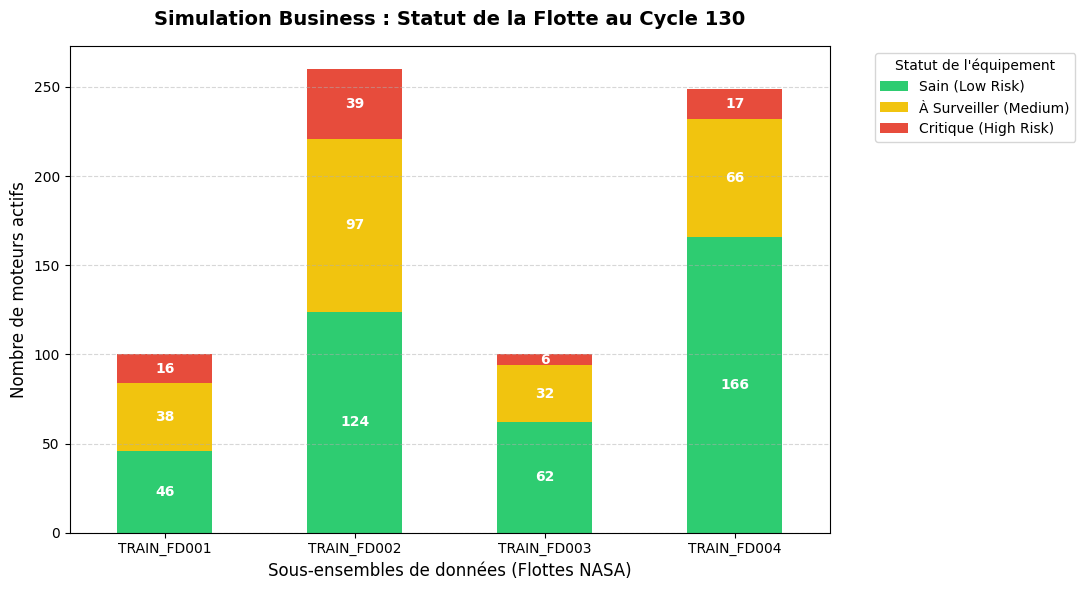

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

risk_data = []
# On simule une inspection de la flotte au cycle 130
cycle_inspection = 130

for name, df in dfs.items():
    # Trouver l'état de chaque moteur au cycle 130 (si le moteur a vécu jusque là, sinon on prend sa fin de vie)
    fleet_at_time = df[df['cycle'] <= cycle_inspection].groupby('engine_id').last().reset_index()
    
    # Compter les segments sur cette photo à l'instant T
    high = fleet_at_time[fleet_at_time['RUL'] <= 30].shape[0]
    med = fleet_at_time[(fleet_at_time['RUL'] > 30) & (fleet_at_time['RUL'] <= 70)].shape[0]
    low = fleet_at_time[fleet_at_time['RUL'] > 70].shape[0]
    
    risk_data.append({
        'Dataset': name.upper(), 
        'Sain (Low Risk)': low, 
        'À Surveiller (Medium)': med, 
        'Critique (High Risk)': high
    })

df_risk = pd.DataFrame(risk_data).set_index('Dataset')

# Génération du graphique multicolore
ax = df_risk.plot(kind='bar', stacked=True, figsize=(11, 6), color=['#2ecc71', '#f1c40f', '#e74c3c'])

plt.title(f"Simulation Business : Statut de la Flotte au Cycle {cycle_inspection}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sous-ensembles de données (Flottes NASA)", fontsize=12)
plt.ylabel("Nombre de moteurs actifs", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Statut de l'équipement", bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotations des chiffres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.annotate(f'{int(height)}', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_27084\2904431114.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.index, y=correlations.values, palette="RdBu_r")


=== RAPPORT D'EXPLOITATION GLOBALE ===
• Nombre total de lignes analysées : 160359
• Capteurs les plus corrélés (强 indicateurs d'usure) : s14, s11
• Capteurs constants/inutiles identifiés sur l'ensemble : ['s2']


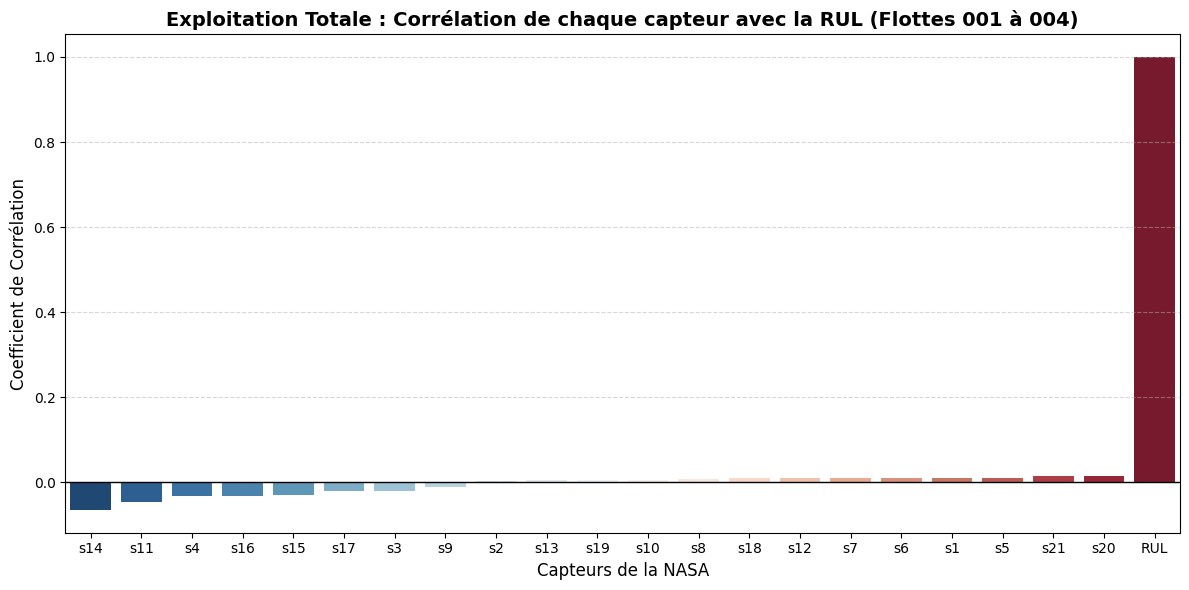

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fusionner l'intégralité des 4 fichiers en un seul grand DataFrame
all_dfs = []
for name, df in dfs.items():
    # On ajoute une colonne pour se souvenir du sous-dataset d'origine
    df_copy = df.copy()
    df_copy['dataset_origin'] = name
    all_dfs.append(df_copy)

df_total = pd.concat(all_dfs, ignore_index=True)

# 2. Calculer la corrélation de tous les capteurs avec la RUL
# Une corrélation proche de 0 signifie que le capteur est inutile sur l'ensemble des fichiers
sensor_cols = [f's{i}' for i in range(1, 22)]
correlations = df_total[sensor_cols + ['RUL']].corr()['RUL'].sort_values()

# 3. Visualisation de l'exploitation totale des capteurs
plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.index, y=correlations.values, palette="RdBu_r")

plt.title("Exploitation Totale : Corrélation de chaque capteur avec la RUL (Flottes 001 à 004)", fontsize=14, fontweight='bold')
plt.xlabel("Capteurs de la NASA", fontsize=12)
plt.ylabel("Coefficient de Corrélation", fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

print(f"=== RAPPORT D'EXPLOITATION GLOBALE ===")
print(f"• Nombre total de lignes analysées : {len(df_total)}")
print(f"• Capteurs les plus corrélés (强 indicateurs d'usure) : {correlations.index[0]}, {correlations.index[1]}")
print(f"• Capteurs constants/inutiles identifiés sur l'ensemble : {list(correlations[round(correlations, 2) == 0].index)}")
print("=======================================")

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np

print("==========================================================")
print("       EXPLOITATION ANALYTIQUE COMPLÈTE DES 4 FLOTTES     ")
print("==========================================================")

# 1. Statistiques globales cumulées sur les 4 fichiers
total_lignes = 0
total_moteurs = 0
all_ruls = []
critical_engines_total = 0

print("🔍 1. MÉTROPLES COMPLÈTES PAR DATASET :")
for name, df in dfs.items():
    lignes_f = len(df)
    moteurs_f = df['engine_id'].nunique()
    
    # RUL moyenne au cours de la vie des moteurs dans ce fichier
    rul_moyenne_f = df['RUL'].mean()
    
    # Prendre la photo au cycle 130 pour ce fichier spécifique
    fleet_130 = df[df['cycle'] <= 130].groupby('engine_id').last()
    critiques_130 = fleet_130[fleet_130['RUL'] <= 30].shape[0]
    
    total_lignes += lignes_f
    total_moteurs += moteurs_f
    critical_engines_total += critiques_130
    
    print(f"\n📊 {name.upper()} :")
    print(f"  • Volume de données    : {lignes_f} lignes analysées")
    print(f"  • Nombre de moteurs    : {moteurs_f} unités suivies")
    print(f"  • RUL Moyenne (Vie)    : {rul_moyenne_f:.1f} cycles de vol")
    print(f"  • Alerte Cycle 130     : {critiques_130} moteurs en danger critique (RUL <= 30)")

print("\n----------------------------------------------------------")
print("📈 2. RÉSUMÉ DE SYNTHÈSE GLOBALE (LIVRABLES RAPPORT) :")
print("----------------------------------------------------------")
print(f"✅ Nombre total de lignes exploitées    : {total_lignes:,} lignes")
print(f"✅ Population totale de turboréacteurs  : {total_moteurs} moteurs uniques")
print(f"✅ Distribution de la cible (RUL Max)   : Min = 0 | Max = {df_total['RUL'].max()} cycles")
print(f"✅ Nombre total d'équipements Critiques : {critical_engines_total} moteurs (Alerte au Cycle 130)")
print("==========================================================")

       EXPLOITATION ANALYTIQUE COMPLÈTE DES 4 FLOTTES     
🔍 1. MÉTROPLES COMPLÈTES PAR DATASET :

📊 TRAIN_FD001 :
  • Volume de données    : 20631 lignes analysées
  • Nombre de moteurs    : 100 unités suivies
  • RUL Moyenne (Vie)    : 107.8 cycles de vol
  • Alerte Cycle 130     : 16 moteurs en danger critique (RUL <= 30)

📊 TRAIN_FD002 :
  • Volume de données    : 53759 lignes analysées
  • Nombre de moteurs    : 260 unités suivies
  • RUL Moyenne (Vie)    : 108.2 cycles de vol
  • Alerte Cycle 130     : 39 moteurs en danger critique (RUL <= 30)

📊 TRAIN_FD003 :
  • Volume de données    : 24720 lignes analysées
  • Nombre de moteurs    : 100 unités suivies
  • RUL Moyenne (Vie)    : 138.1 cycles de vol
  • Alerte Cycle 130     : 6 moteurs en danger critique (RUL <= 30)

📊 TRAIN_FD004 :
  • Volume de données    : 61249 lignes analysées
  • Nombre de moteurs    : 249 unités suivies
  • RUL Moyenne (Vie)    : 133.3 cycles de vol
  • Alerte Cycle 130     : 17 moteurs en danger critique